## Load data 

In [57]:
import pandas as pd 

df = pd.read_csv('cleand_hr_data.csv')

### EDA

In [58]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15002 entries, 0 to 15001
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     15002 non-null  float64
 1   last_evaluation        15002 non-null  float64
 2   number_project         15002 non-null  int64  
 3   average_monthly_hours  15002 non-null  int64  
 4   time_spend_company     15002 non-null  int64  
 5   Work_accident          15002 non-null  int64  
 6   employee_left          15002 non-null  int64  
 7   promotion_last_5years  15002 non-null  int64  
 8   department             15002 non-null  str    
 9   salary                 15002 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,employee_left,promotion_last_5years
count,15002.000000,15002.000000,15002.000000,15002.000000,15002.000000,15002.000000,15002.000000,15002.000000
mean,0.612839,0.716068,3.802693,201.041728,3.498067,0.144581,0.238235,0.021264
std,0.248607,0.171179,1.232733,49.941815,1.460053,0.351689,0.426018,0.144267
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [59]:
df['employee_left'].value_counts()

employee_left
0    11428
1     3574
Name: count, dtype: int64

#### Heatmap

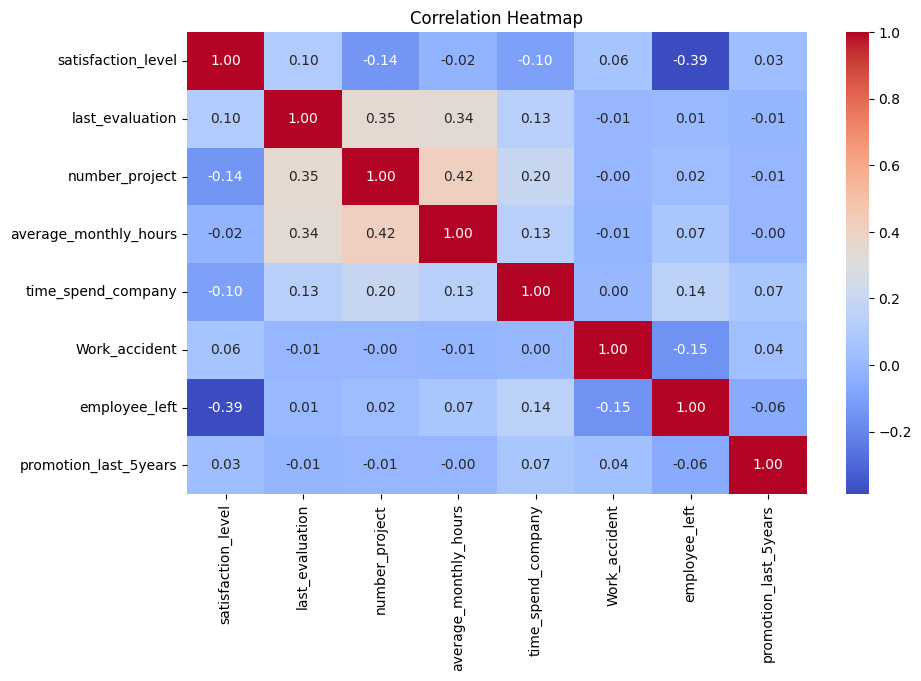

In [60]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Insights

> Satisfaction Level shows the strongest negative correlation with attrition (-0.39), indicating that employees with lower satisfaction are significantly more likely to leave.

>Time Spent at Company has a slight positive relationship with attrition (0.14), suggesting attrition increases with tenure up to a certain point.

>Work Accidents are negatively correlated with attrition (-0.15), meaning employees involved in workplace incidents were less likely to leave.

>Number of Projects and Monthly Hours are moderately correlated (0.42), indicating employees with more projects tend to work longer hours.

C:\Users\wardo\AppData\Local\Temp\ipykernel_20428\3861799879.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


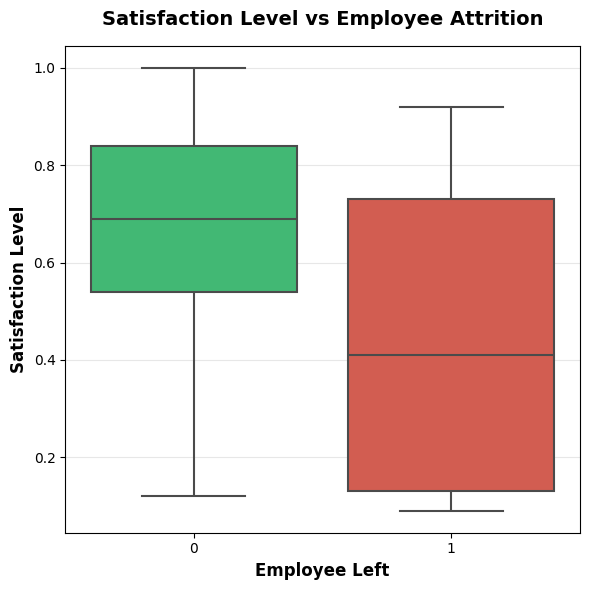

In [ ]:
# Satisfaction Level vs Attrition

plt.figure(figsize=(6, 6))

ax = sns.boxplot(
    data=df,
    x='employee_left',
    y='satisfaction_level',
    palette=['#2ecc71', '#e74c3c'], 
    linewidth=1.5,
    fliersize=4,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5)
)

# Customize title and labels
plt.title("Satisfaction Level vs Employee Attrition", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Employee Left", fontsize=12, fontweight='semibold')
plt.ylabel("Satisfaction Level", fontsize=12, fontweight='semibold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

### Satisfaction Level vs Employee Attrition Insights

>Employees who left the company had significantly lower satisfaction levels compared to those who stayed.

> The median satisfaction score of employees who left is substantially lower than that of retained employees.

>Employee satisfaction appears to be one of the most important drivers of attrition.

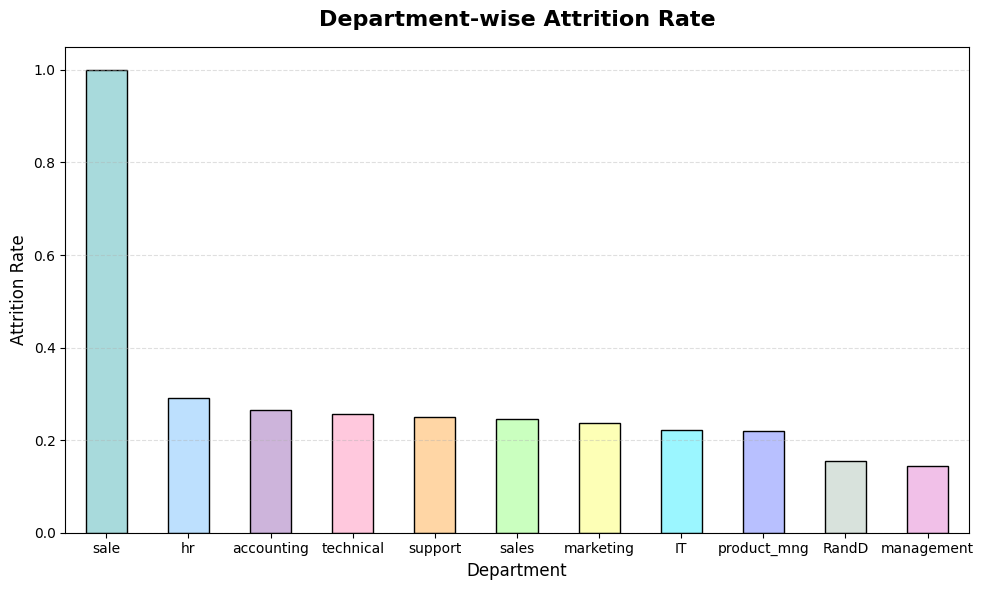

In [62]:
# Department vs Attrition Rate

dept_attrition  = df.groupby('department')['employee_left'].mean().sort_values(ascending=False)
colors = ['#A8DADC', '#BDE0FE', '#CDB4DB', '#FFC8DD', '#FFD6A5', '#CAFFBF', '#FDFFB6', '#9BF6FF', '#B8C0FF', '#D8E2DC', '#F1C0E8']
plt.figure(figsize=(10,6))

dept_attrition.plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)
plt.title(
    "Department-wise Attrition Rate",
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Attrition Rate", fontsize=12)
plt.xticks(rotation=0,fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

### Department-wise Attrition Rate Insights

>HR recorded the highest attrition rate among major departments (~29%).

>Accounting and Technical departments also experienced relatively high turnover.

>Management and R&D showed the lowest attrition rates, indicating stronger employee retention.

>The Sales department had a moderate attrition rate despite having the largest workforce.

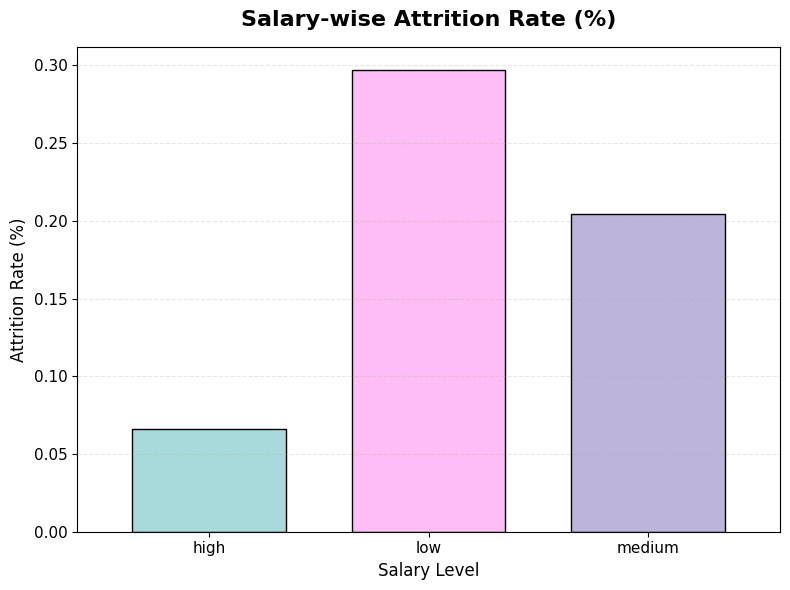

In [63]:
# Salary vs Attrition Rate

salary_attrition = df.groupby('salary')['employee_left'].mean()

colors = ['#A8DADC', "#FEBDF4", "#BDB4DB"]

plt.figure(figsize=(8,6))
salary_attrition.plot(
    kind='bar',
    color=colors,
    edgecolor='black',
    width=0.7
)
plt.title(
    'Salary-wise Attrition Rate (%)',
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel('Salary Level', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout() 

### Salary-wise Attrition Rate Insights

>Employees in the low-salary category experienced the highest attrition rate (~30%).

>Attrition decreased significantly as salary levels increased.

>High-salary employees had the lowest turnover rate (~7%).

>Compensation appears to be a major factor influencing employee retention.

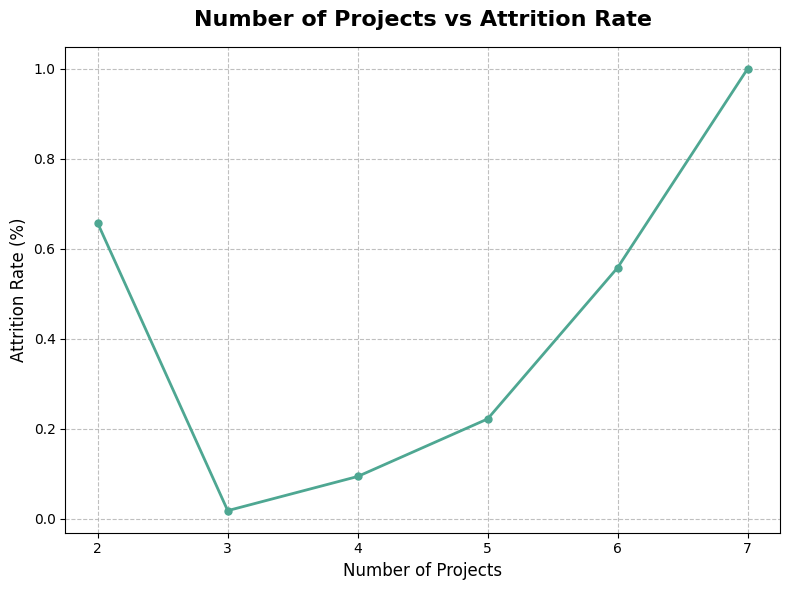

In [64]:
# Number of Projects vs Attrition Rate

project_attrition = df.groupby('number_project')['employee_left'].mean()

plt.figure(figsize=(8,6))

project_attrition.plot(
    kind='line',
    marker='o',
    linewidth=2,
    markersize=5,
    color="#4EA792"
)

plt.title(
    "Number of Projects vs Attrition Rate",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel("Number of Projects", fontsize=12)
plt.ylabel("Attrition Rate (%)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.8)
plt.tight_layout()

### Number of Projects vs Attrition Rate Insights

>Employees handling only 2 projects exhibited extremely high attrition rates.

>Attrition remained relatively low for employees managing 3–5 projects.

>Attrition increased sharply for employees assigned 6–7 projects.

>The results suggest both underutilization and excessive workload contribute to employee turnover.

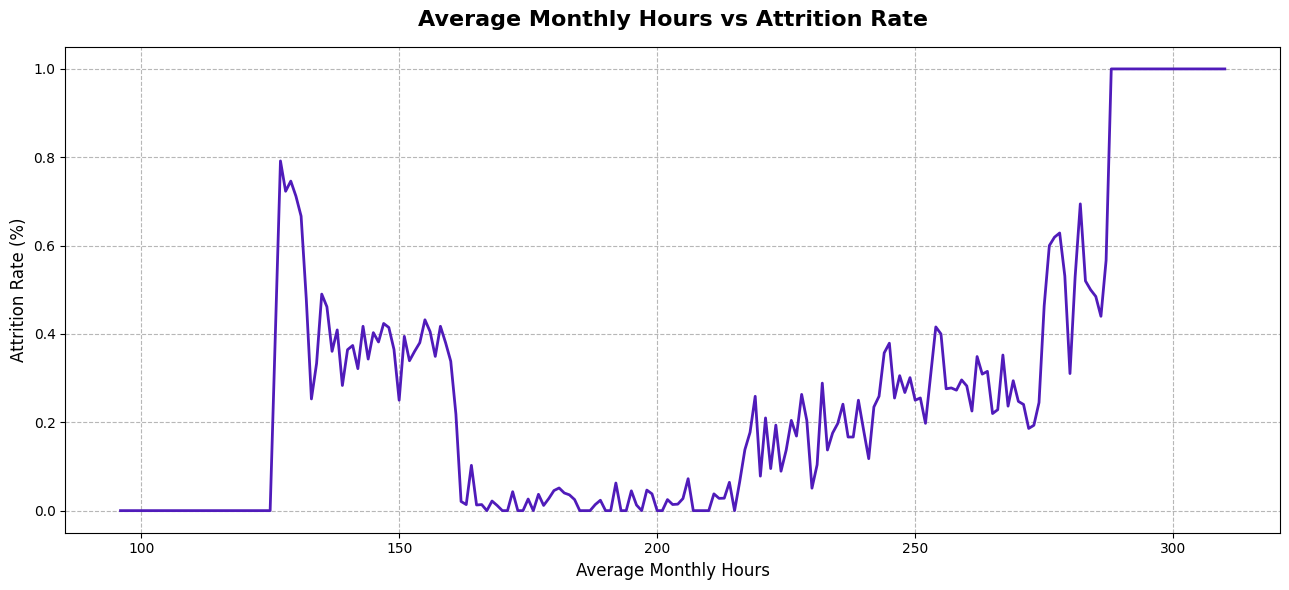

In [65]:
# Average Monthly Hours vs Attrition Rate

hours_attrition = df.groupby('average_monthly_hours')['employee_left'].mean()

plt.figure(figsize=(13,6))

hours_attrition.plot(
    kind='line',
    color="#501BBA",
    linewidth=2
)

plt.title(
    'Average Monthly Hours vs Attrition Rate',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel('Average Monthly Hours', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)

plt.grid(
    True,
    linestyle='--',
    alpha=0.9
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

### Average Monthly Hours vs Attrition Rate Insights

>Employees working very high monthly hours experienced significantly higher attrition rates.

>Attrition remained relatively low for employees with moderate workloads.

>The trend suggests employee burnout may be a major contributor to turnover.

>Excessive working hours are associated with increased employee departure risk.

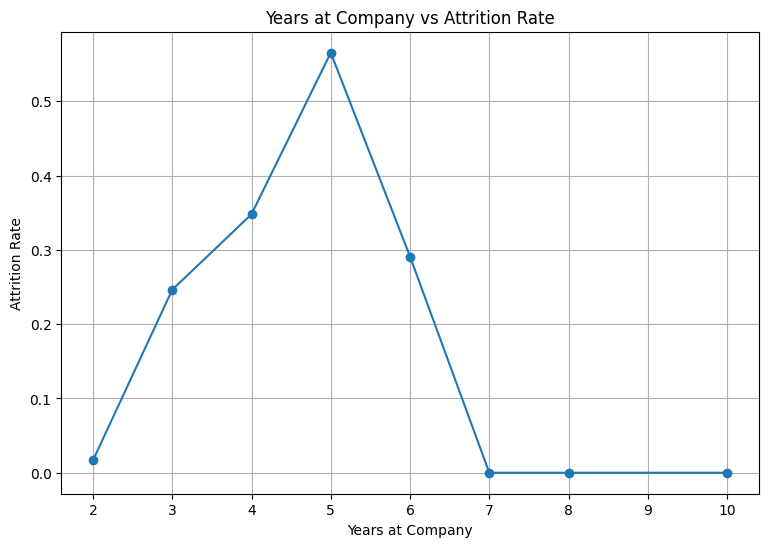

In [66]:
# Time Spent in Company vs Attrition Rate

tenure_attrition = (df.groupby('time_spend_company')['employee_left'].mean())

plt.figure(figsize=(9,6))

tenure_attrition.plot(
    kind='line',
    marker='o'
)

plt.title("Years at Company vs Attrition Rate")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate")

plt.grid(True)

plt.show()

### Years at Company vs Attrition Rate Insights

>Attrition increased steadily from 2 to 5 years of tenure.

>Employees with approximately 5 years at the company showed the highest attrition rate.

>After 6 years, attrition declined considerably.

>Mid-tenure employees appear to be the most vulnerable group for employee turnover.

## Overall Business Insights

>Employee satisfaction is the strongest predictor of attrition.

>Low salary levels are strongly associated with higher employee turnover.

>Both underworked and overworked employees demonstrate elevated attrition rates.

>Employees with heavy workloads and long working hours are at greater risk of leaving.

>HR, Accounting, and Technical departments require targeted retention strategies due to higher turnover rates.

>Employees reaching the 4–5 year tenure range represent a critical retention segment.

>Promotion opportunities appear limited and may contribute indirectly to attrition.

>Maintaining competitive compensation, balanced workloads, and employee engagement programs can significantly improve retention outcomes.

>Workforce retention efforts should primarily focus on low-satisfaction, low-salary, and high-workload employees, as these groups exhibit the highest attrition risk.

In [67]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,employee_left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
